# Import dan Konfigurasi Path

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings

warnings.filterwarnings("ignore")

from config import (
    RAW_DATASET_PATH, FIGURES_DIR,
    COLUMNS_TO_DROP, TARGET_COLUMN
)

# Style visualisasi
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("Set2")

print(f"Dataset path: {RAW_DATASET_PATH}")
print(f"File exists : {RAW_DATASET_PATH.exists()}")

Dataset path: D:\fraud-detection-blockchain\data\raw\PS_20174392719_1491204439457_log.csv
File exists : True


# Load Dataset dan Info Awal

In [2]:
print("Memuat dataset...")

df = pd.read_csv(RAW_DATASET_PATH)

print(f"\nUkuran dataset: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Memori digunakan: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nKolom: {list(df.columns)}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nRange step: {df['step'].min()} – {df['step'].max()}")
print(f"Simulasi: {df['step'].max() / 24:.1f} hari")

Memuat dataset...

Ukuran dataset: 6,362,620 baris × 11 kolom
Memori digunakan: 1675.8 MB

Kolom: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Tipe data:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Range step: 1 – 743
Simulasi: 31.0 hari


# Analisis Distribusi Kelas

Legitimate :  6,354,407  (99.87%)
Fraud      :      8,213  (0.1291%)
Rasio imbalance: 1 fraud per 773 transaksi


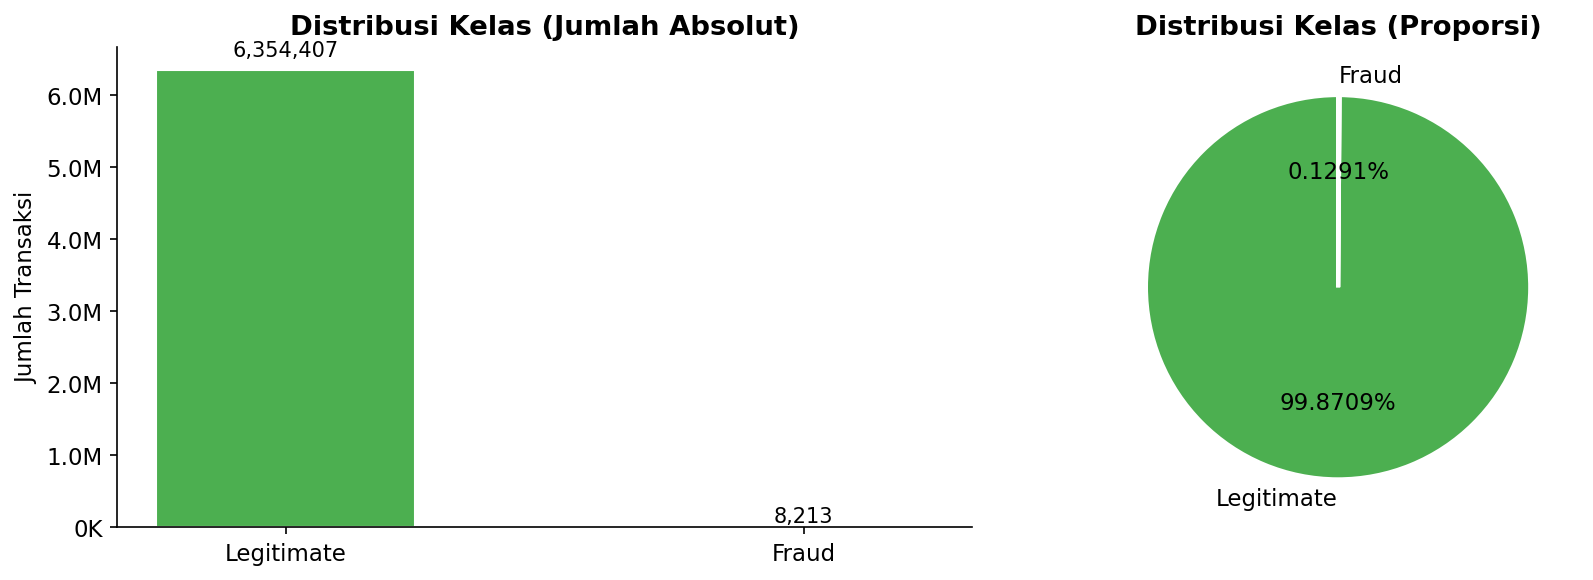

Gambar disimpan: D:\fraud-detection-blockchain\reports\figures\01_class_distribution.png


In [3]:
fraud_count = df[TARGET_COLUMN].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100

print(f"Legitimate : {legit_count:>10,}  ({100 - fraud_pct:.2f}%)")
print(f"Fraud      : {fraud_count:>10,}  ({fraud_pct:.4f}%)")
print(f"Rasio imbalance: 1 fraud per {int(legit_count/fraud_count):,} transaksi")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = [legit_count, fraud_count]
labels = ["Legitimate", "Fraud"]
colors = ["#4CAF50", "#F44336"]

bars = axes[0].bar(labels, counts, color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Distribusi Kelas (Jumlah Absolut)", fontweight="bold")
axes[0].set_ylabel("Jumlah Transaksi")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"
))
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f"{count:,}", ha="center", va="bottom", fontsize=10)

# Pie chart (persentase)
wedges, texts, autotexts = axes[1].pie(
    counts, labels=labels, colors=colors,
    autopct="%1.4f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Distribusi Kelas (Proporsi)", fontweight="bold")

plt.tight_layout()
save_path = FIGURES_DIR / "01_class_distribution.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Gambar disimpan: {save_path}")

# Analisis Tipe Transaksi
Distribusi Tipe Transaksi dan Fraud Rate per Tipe

Statistik per tipe transaksi:
    type   total  fraud  fraud_rate
CASH_OUT 2237500   4116    0.183955
 PAYMENT 2151495      0    0.000000
 CASH_IN 1399284      0    0.000000
TRANSFER  532909   4097    0.768799
   DEBIT   41432      0    0.000000


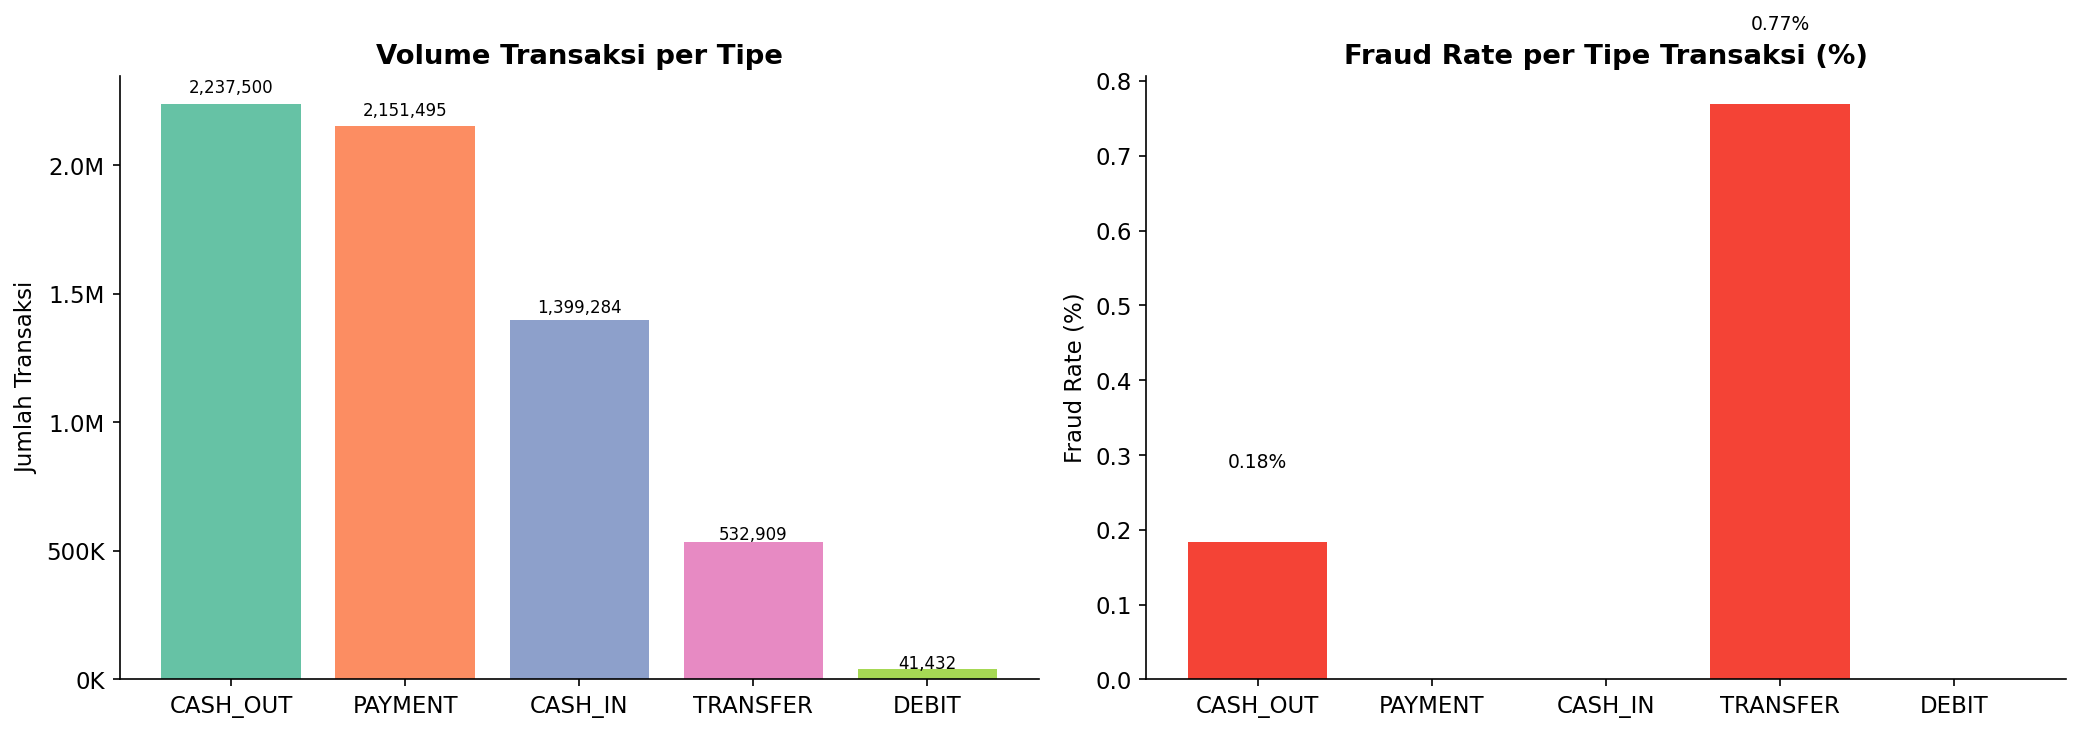


Catatan: Fraud HANYA terjadi pada tipe: ['CASH_OUT', 'TRANSFER']
Gambar disimpan: D:\fraud-detection-blockchain\reports\figures\02_transaction_type_analysis.png


In [4]:
type_stats = df.groupby("type").agg(
    total=("isFraud", "count"),
    fraud=("isFraud", "sum")
).reset_index()
type_stats["fraud_rate"] = type_stats["fraud"] / type_stats["total"] * 100
type_stats = type_stats.sort_values("total", ascending=False)

print("Statistik per tipe transaksi:")
print(type_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume per tipe
axes[0].bar(type_stats["type"], type_stats["total"],
            color=sns.color_palette("Set2", len(type_stats)))
axes[0].set_title("Volume Transaksi per Tipe", fontweight="bold")
axes[0].set_ylabel("Jumlah Transaksi")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"
))
for i, row in type_stats.iterrows():
    axes[0].text(list(type_stats["type"]).index(row["type"]),
                 row["total"] * 1.02,
                 f"{row['total']:,}", ha="center", fontsize=8)

# Fraud rate per tipe
bar_colors = ["#F44336" if r > 0 else "#E0E0E0"
              for r in type_stats["fraud_rate"]]
axes[1].bar(type_stats["type"], type_stats["fraud_rate"], color=bar_colors)
axes[1].set_title("Fraud Rate per Tipe Transaksi (%)", fontweight="bold")
axes[1].set_ylabel("Fraud Rate (%)")
for i, row in type_stats.iterrows():
    if row["fraud_rate"] > 0:
        idx = list(type_stats["type"]).index(row["type"])
        axes[1].text(idx, row["fraud_rate"] + 0.1,
                     f"{row['fraud_rate']:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
save_path = FIGURES_DIR / "02_transaction_type_analysis.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"\nCatatan: Fraud HANYA terjadi pada tipe: "
      f"{list(type_stats[type_stats['fraud_rate'] > 0]['type'])}")
print(f"Gambar disimpan: {save_path}")

# Analisis Fitur Numerik

=== Statistik Deskriptif (Fraud vs Legitimate) ===

--- amount ---
                count        mean         std   min        25%        50%  \
Legitimate  6354407.0   178197.04   596236.98  0.01   13368.40   74684.72   
Fraud          8213.0  1467967.30  2404252.95  0.00  127091.33  441423.44   

                   75%          max  
Legitimate   208364.76  92445516.64  
Fraud       1517771.48  10000000.00  

--- oldbalanceOrg ---
                count        mean         std  min        25%        50%  \
Legitimate  6354407.0   832828.71  2887144.03  0.0       0.00   14069.00   
Fraud          8213.0  1649667.61  3547719.44  0.0  125822.44  438983.45   

                   75%          max  
Legitimate   106969.50  43818855.30  
Fraud       1517771.48  59585040.37  

--- newbalanceOrig ---
                count       mean         std  min  25%  50%        75%  \
Legitimate  6354407.0  855970.23  2924986.96  0.0  0.0  0.0  144730.74   
Fraud          8213.0  192392.63  1965666.46  0.0

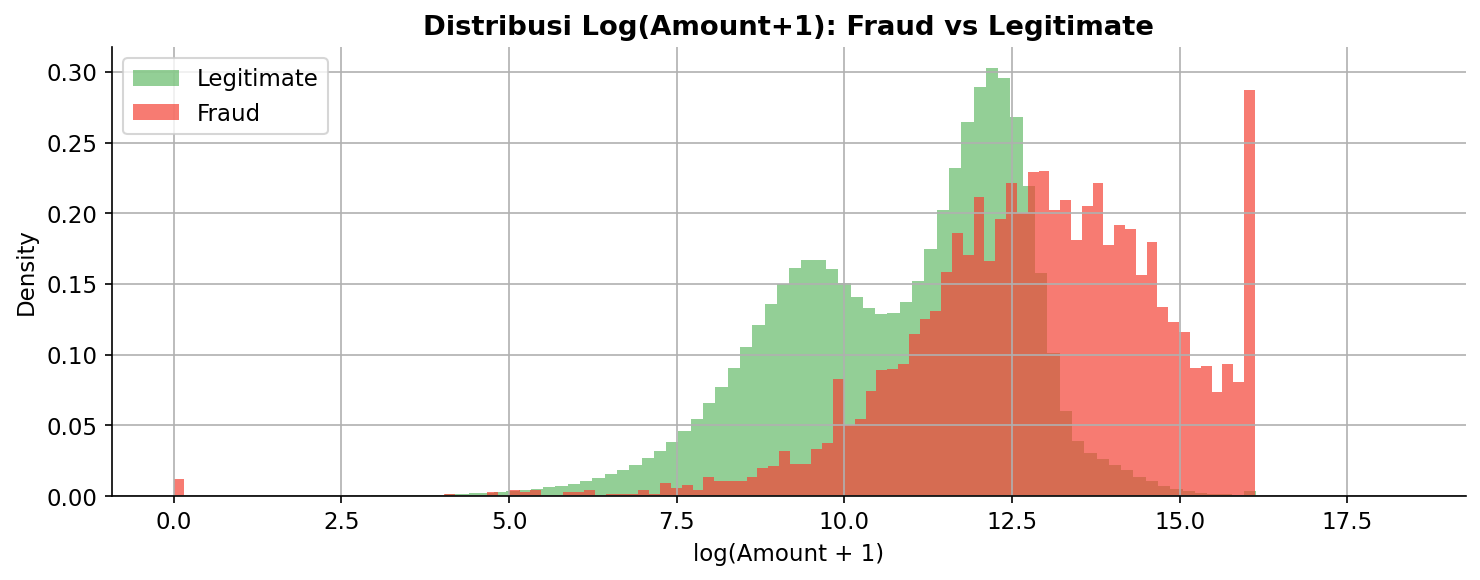

Gambar disimpan: D:\fraud-detection-blockchain\reports\figures\03_amount_distribution.png


In [5]:
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
                "oldbalanceDest", "newbalanceDest"]

print("=== Statistik Deskriptif (Fraud vs Legitimate) ===\n")
for col in numeric_cols:
    print(f"--- {col} ---")
    stats = df.groupby("isFraud")[col].describe()
    stats.index = ["Legitimate", "Fraud"]
    print(stats.round(2))
    print()

# Distribusi amount (log scale): fraud vs legitimate
fig, ax = plt.subplots(figsize=(10, 4))
df[df["isFraud"] == 0]["amount"].apply(np.log1p).hist(
    bins=100, ax=ax, alpha=0.6, label="Legitimate",
    color="#4CAF50", density=True)
df[df["isFraud"] == 1]["amount"].apply(np.log1p).hist(
    bins=100, ax=ax, alpha=0.7, label="Fraud",
    color="#F44336", density=True)
ax.set_title("Distribusi Log(Amount+1): Fraud vs Legitimate", fontweight="bold")
ax.set_xlabel("log(Amount + 1)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
save_path = FIGURES_DIR / "03_amount_distribution.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Gambar disimpan: {save_path}")

# Analisis Temporal
Pola fraud berdasarkan waktu (hour dan day)

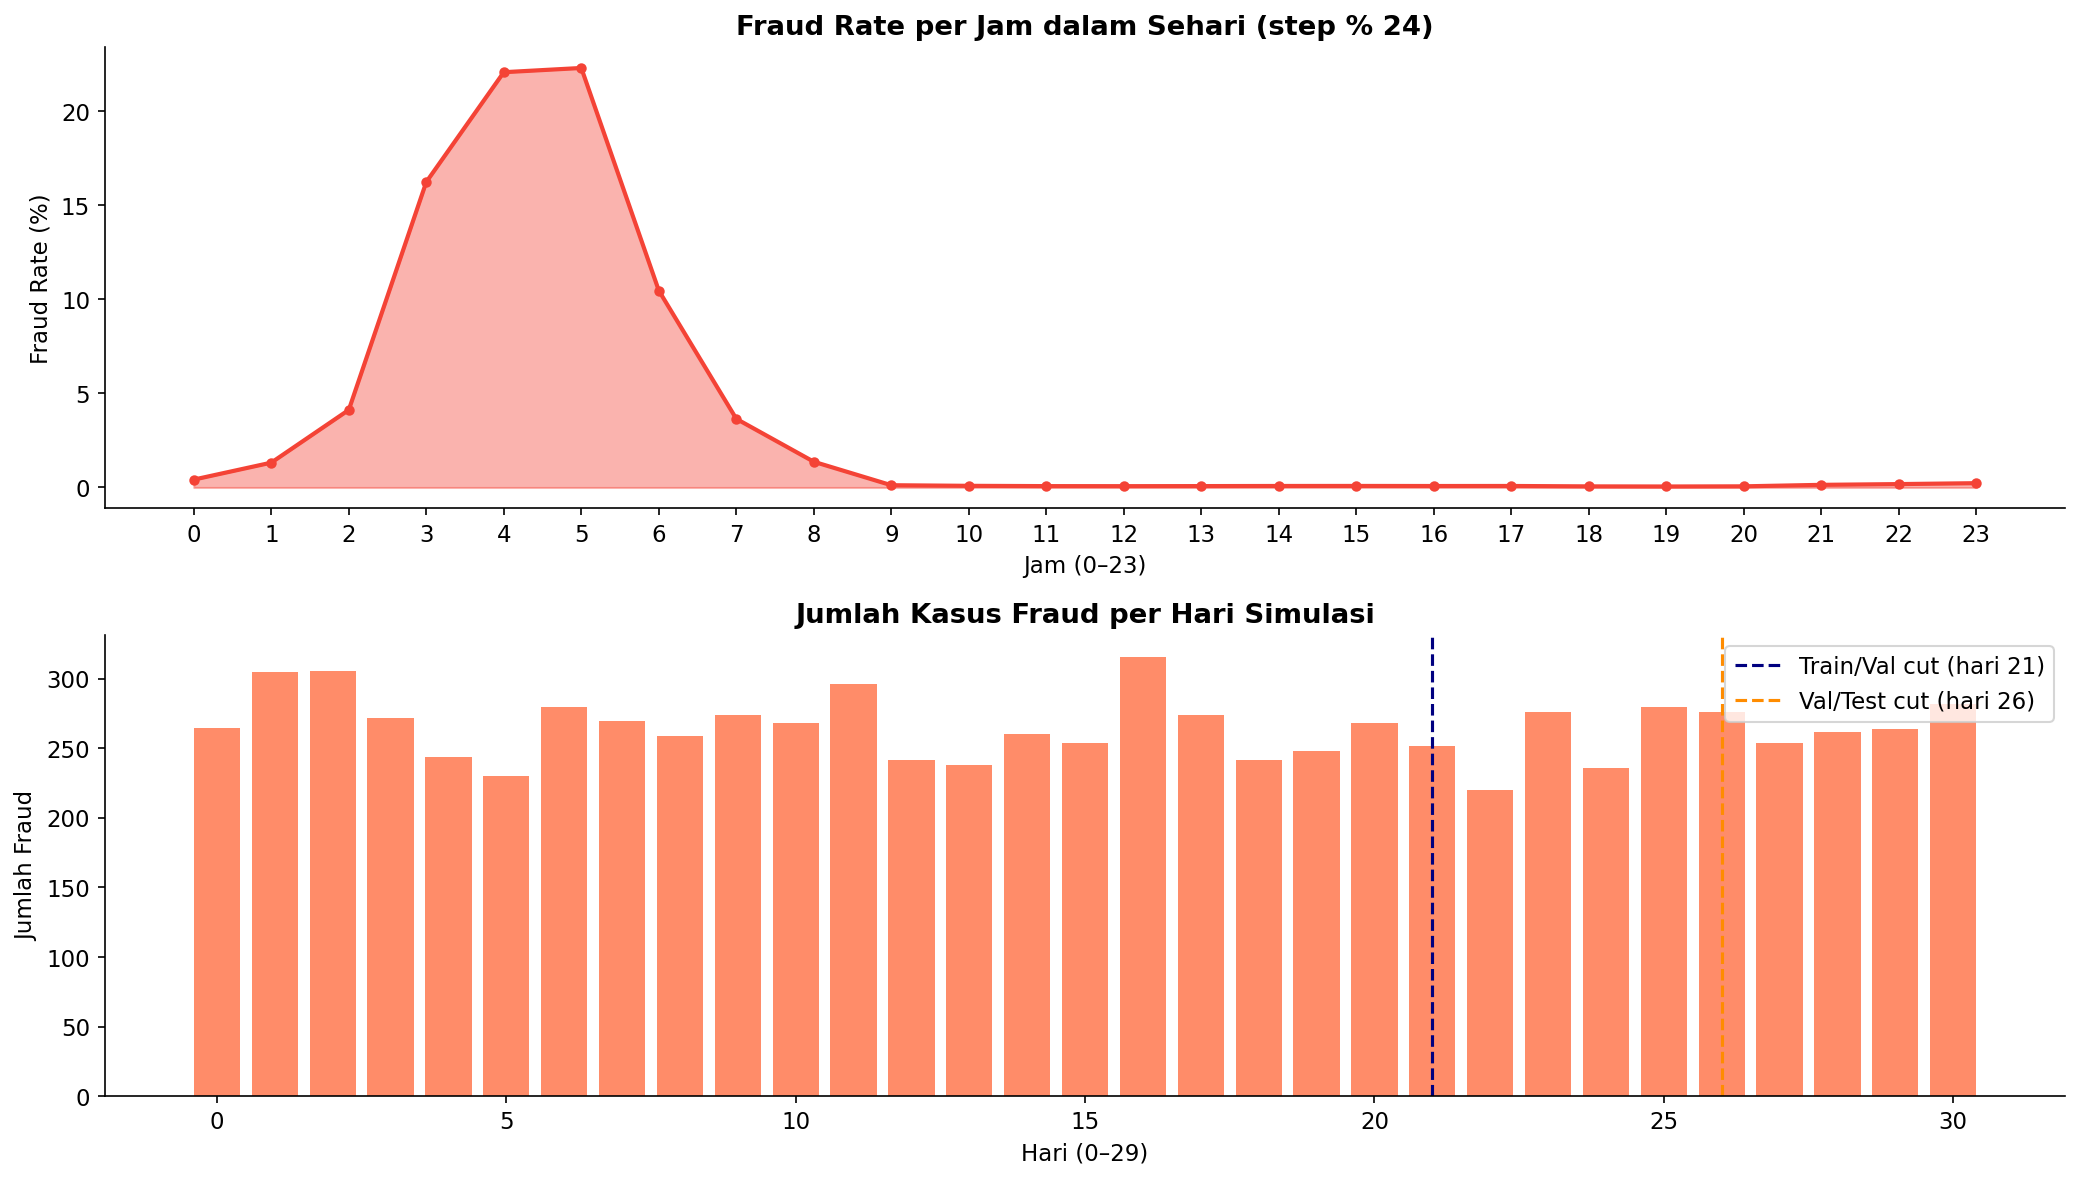

Gambar disimpan: D:\fraud-detection-blockchain\reports\figures\04_temporal_analysis.png


In [6]:
df["hour"] = df["step"] % 24
df["day"]  = df["step"] // 24

hourly = df.groupby("hour")["isFraud"].agg(["sum", "count"])
hourly["rate"] = hourly["sum"] / hourly["count"] * 100

daily = df.groupby("day")["isFraud"].agg(["sum", "count"])
daily["rate"] = daily["sum"] / daily["count"] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Fraud rate per jam
axes[0].fill_between(hourly.index, hourly["rate"],
                     alpha=0.4, color="#F44336")
axes[0].plot(hourly.index, hourly["rate"],
             color="#F44336", linewidth=2, marker="o", markersize=4)
axes[0].set_title("Fraud Rate per Jam dalam Sehari (step % 24)",
                  fontweight="bold")
axes[0].set_xlabel("Jam (0–23)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_xticks(range(0, 24))

# Jumlah fraud per hari
axes[1].bar(daily.index, daily["sum"],
            color="#FF7043", alpha=0.8, width=0.8)
axes[1].set_title("Jumlah Kasus Fraud per Hari Simulasi",
                  fontweight="bold")
axes[1].set_xlabel("Hari (0–29)")
axes[1].set_ylabel("Jumlah Fraud")

# garis vertikal: posisi split train/val/test
max_step = df["step"].max()
train_cut = int(max_step * 0.70) // 24
val_cut   = int(max_step * 0.85) // 24
axes[1].axvline(x=train_cut, color="navy", linestyle="--",
                linewidth=1.5, label=f"Train/Val cut (hari {train_cut})")
axes[1].axvline(x=val_cut, color="darkorange", linestyle="--",
                linewidth=1.5, label=f"Val/Test cut (hari {val_cut})")
axes[1].legend()

plt.tight_layout()
save_path = FIGURES_DIR / "04_temporal_analysis.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

# Hapus kolom sementara (akan dibuat ulang di preprocessing)
df.drop(columns=["hour", "day"], inplace=True)
print(f"Gambar disimpan: {save_path}")

# Analisis Korelasi 
Correlation heatmap fitur numerik

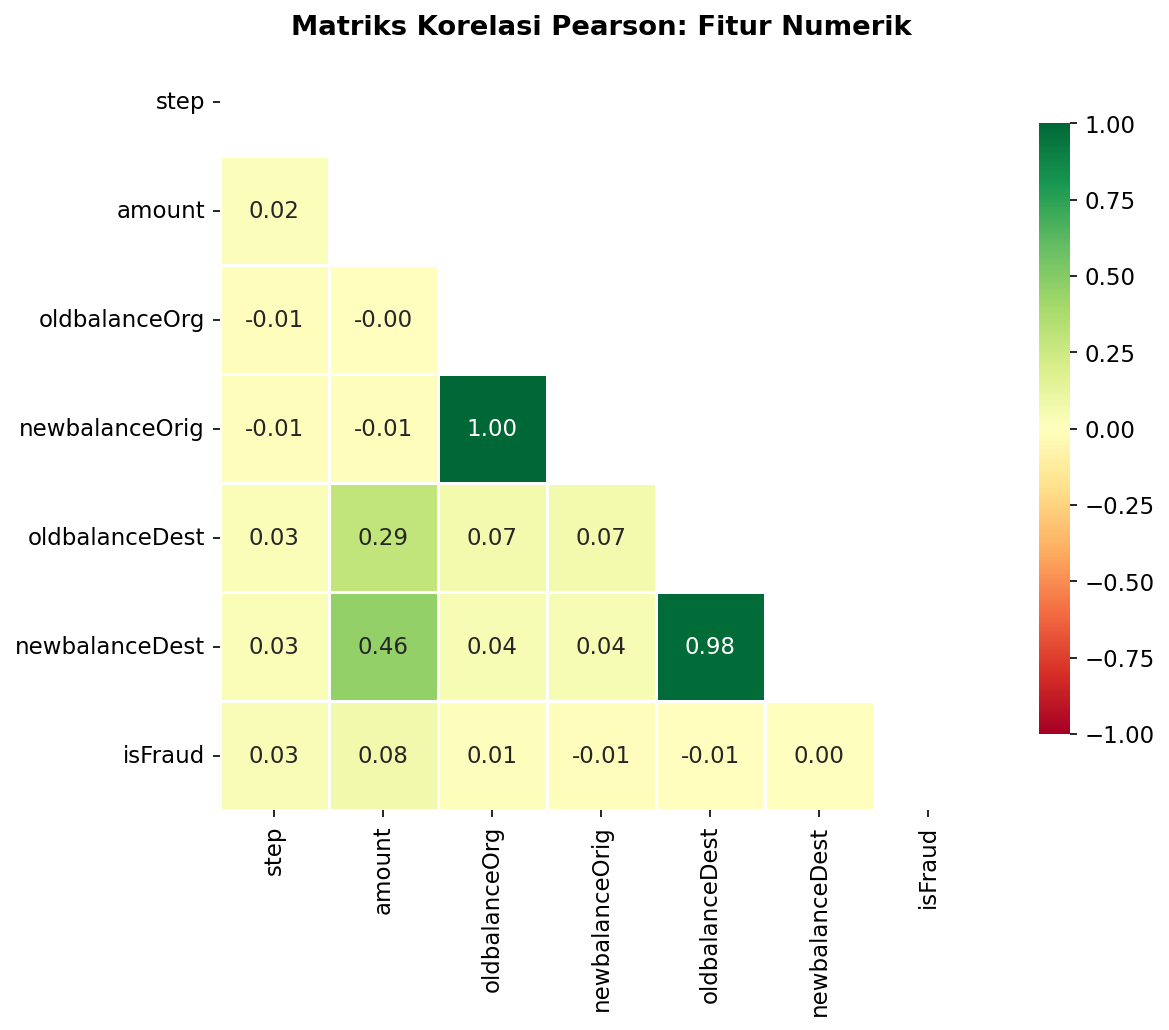

Gambar disimpan: D:\fraud-detection-blockchain\reports\figures\05_correlation_heatmap.png


In [7]:
# Mengambil subset fraud untuk korelasi (lebih representatif)
numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
                "oldbalanceDest", "newbalanceDest", "isFraud"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Matriks Korelasi Pearson: Fitur Numerik", fontweight="bold")
plt.tight_layout()
save_path = FIGURES_DIR / "05_correlation_heatmap.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Gambar disimpan: {save_path}")

# Ringkasan EDA
Menyimpan statistik EDA ke file JSON

In [8]:
eda_summary = {
    "total_rows": int(len(df)),
    "total_columns": int(df.shape[1]),
    "fraud_count": int(df["isFraud"].sum()),
    "legitimate_count": int((df["isFraud"] == 0).sum()),
    "fraud_percentage": float(df["isFraud"].mean() * 100),
    "step_range": {"min": int(df["step"].min()),
                   "max": int(df["step"].max())},
    "simulation_days": float(df["step"].max() / 24),
    "fraud_by_type": type_stats.set_index("type")[
        ["total", "fraud", "fraud_rate"]].to_dict(),
    "missing_values": df.isnull().sum().to_dict(),
    "duplicate_rows": int(df.duplicated().sum()),
    "memory_mb": float(df.memory_usage(deep=True).sum() / 1e6),
}

import json
save_path = FIGURES_DIR / "eda_summary.json"
with open(save_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

print("=== RINGKASAN EDA ===")
print(f"Total baris          : {eda_summary['total_rows']:,}")
print(f"Fraud                : {eda_summary['fraud_count']:,} "
      f"({eda_summary['fraud_percentage']:.4f}%)")
print(f"Missing values       : {sum(eda_summary['missing_values'].values())}")
print(f"Duplikat             : {eda_summary['duplicate_rows']}")
print(f"Range step           : {eda_summary['step_range']}")
print(f"Fraud hanya pada     : CASH_OUT dan TRANSFER")
print(f"\nRingkasan disimpan : {save_path}")
print("\nEDA selesai!")

=== RINGKASAN EDA ===
Total baris          : 6,362,620
Fraud                : 8,213 (0.1291%)
Missing values       : 0
Duplikat             : 0
Range step           : {'min': 1, 'max': 743}
Fraud hanya pada     : CASH_OUT dan TRANSFER

Ringkasan disimpan : D:\fraud-detection-blockchain\reports\figures\eda_summary.json

EDA selesai!
